# AdaBoost Ensemble Learning & Face Detection

Ensemble classification using AdaBoost and Haar-like feature extractors, trained on facial datasets and evaluated on historical photographs (e.g., 1927 Solvay Conference).


In [2]:
%reload_ext autoreload
%autoreload 2

import numpy as np
from matplotlib import pyplot as plt
from scipy import io as sio

from utils import GenerateHaarFeatureMasks, GenerateTrainTestData, ExtractHaarFeatures
from utils import PlotErrorGraphs, PlotClassifications, PlotSelectedHaarFeatures, PlotHaarFeatureDemonstration, PlotSolvayHeatmap
plt.rcParams['figure.facecolor']='white'

# Load data
faces = sio.loadmat('Data/faces.mat')['faces'].astype("float")
nonfaces = sio.loadmat('Data/nonfaces.mat')['nonfaces'].astype("float")

In [3]:
# Print the exact dimensions of the 3D arrays
print(f"Faces dataset shape: {faces.shape}")
print(f"Non-faces dataset shape: {nonfaces.shape}")

# Print just the total number of images in each dataset (the 3rd dimension)
print(f"Total face images: {faces.shape[2]}")
print(f"Total non-face images: {nonfaces.shape[2]}")

Faces dataset shape: (24, 24, 4916)
Non-faces dataset shape: (24, 24, 7872)
Total face images: 4916
Total non-face images: 7872


### ***! IMPORTANT NOTE !***

> **Implementation Note**: This module is implemented using pure NumPy to demonstrate the core mathematical mechanics from first principles without high-level library abstractions.

---
### **1 Introduction**
In this assignment you will explore a branch of supervised learning called *Ensemble lerning*, specifically using the algorithm known as *AdaBoost*. This algorithm trains multiple simple *weak classifiers* that are later combined into a *strong classifier* which is significantly more powerful than the individual *weak classifiers*. The *weak classifier* you will work with is a simple type of binary classifier called decision stump. These classify scalar inputs based on a single comparisson with a threshold.

![](NotebookMaterials/DecisionStump.png "Decision stump")

In order to apply this classifier to images, we require a way to describe the features of the images using a single number that the decision stump can compare to the threshold. In a seminal article by Viola and Jones, called [Robust real-time object detection](https://www.researchgate.net/publication/215721846_Robust_Real-Time_Object_Detection), this was demonstrated using so called Haar-features, which is what we will use in this assignment.

A Haar-feature is a simple yet surprisingly effective way to quantify edges and gradients in images, by computing the weighted sum of different areas of the image. We will begin by exploring how these Haar-features work, in order to understand the fundamental building blocks of the algorithm you will implement later.

Run the following code cell to generate a random Haar-feature, select a random face and nonface image, and compute the feature values by applying the Haar-feature to the images.

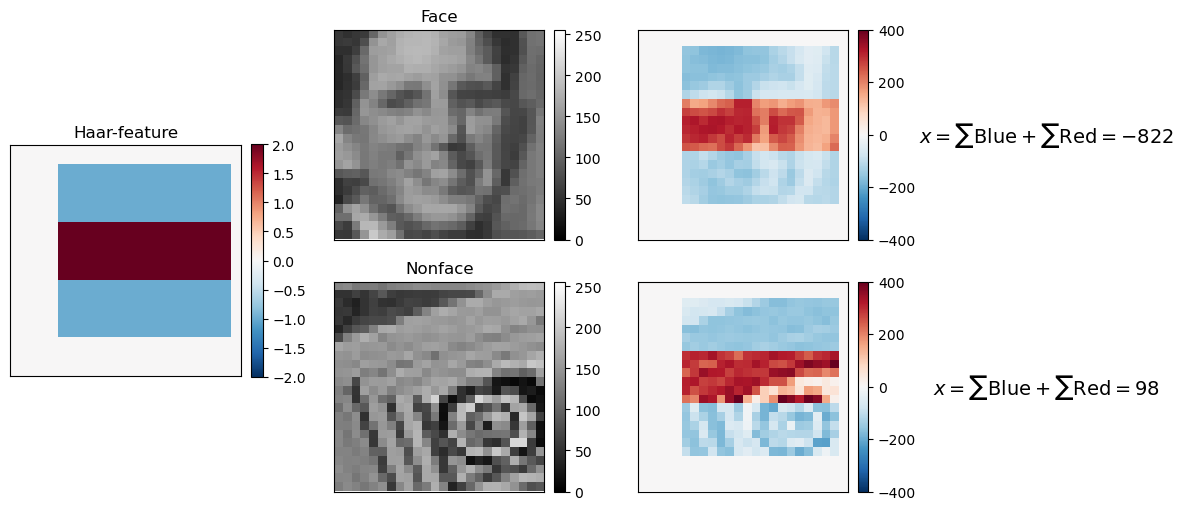

In [57]:
# Generate random Haar-feature and select a random face and a random non-face
randomHaarFeatureMask = GenerateHaarFeatureMasks(1)[:,:,0]
randomFace = faces[:,:,np.random.randint(faces.shape[2])]
randomNonFace = nonfaces[:,:,np.random.randint(nonfaces.shape[2])]

PlotHaarFeatureDemonstration(haar=randomHaarFeatureMask, face=randomFace, nonface=randomNonFace)

NOTES: The leftmost image shows a simple rectangular filter divided into two halves.
- The blue top half represents negative weights (around -1.0 to -1.5, according to the color bar), and the orange/red bottom half represents positive weights (around +1.0).
- This specific "horizontal edge" feature is designed to detect horizontal bands of contrast—specifically, a darker region sitting directly above a lighter region.

The Input Images (Middle Panels)
- Face (Top): A standard grayscale image of a human face. In a typical human face, the region around the eyes is generally darker (due to shadows and eye color) than the upper cheeks just below them.  
- Nonface (Bottom): A relatively uniform, flat grayscale image patch, likely representing background noise.

The Math: The formula $x = \sum \text{Blue} + \sum \text{Red}$ means the algorithm takes the sum of the pixel intensities in the blue area (multiplied by their negative weights) and adds it to the sum of the pixel intensities in the red area (multiplied by their positive weights). Essentially, it's calculating the difference in brightness between the two regions.

Face Result ($x = -1812$): Because the eye region and cheek region have very different brightness levels, subtracting one from the other yields a number with a large magnitude (-1812). This strong signal tells the algorithm, "There is a distinct contrast edge here," which is a strong indicator of a face.

The Haar-features we generate in this assignment consist of either two or three areas, each with a scaling factor of -1, 1, or 2. The pixels outside the Haar-feature has a scaling of 0. The images are pixel-wise multiplied with the Haar-feature, after which the entire image is summed to a single scalar value. This weighted sum of pixels is the feature value of the image, which can be used in the weak classifier.

Of course, since the Haar-feature in this picture is chosen entierly at random, we should not expect that it makes sense as a good feature extractor. Finding a good set of Haar-features is your task, but we will get back to that soon. Before that, take a look at the decision stump classifier again. Now that we know how to extract a single feature value from an image, we can see how a desision stump can be used to classify the images as faces or nonfaces. We can write the decision stump as a function:

$$
\large
f(x \: | \: \tau) =
\begin{cases}
    +1 & \text{if } x \geq \tau \\
    -1 & \text{if } x < \tau
\end{cases}
$$

As you have already seen in the lecture on boosting and ensemble learning, this can also be extended to a more general definition by including a polarity parameter:

$$
\large
f(x \: | \: \tau, p) =
\begin{cases}
    +1 & \text{if } px \geq p\tau \\
    -1 & \text{if } px < p\tau
\end{cases}
$$

By selecting $p$ equal to +1 or -1, we can flip the sign of the predicted output. Since this is a binary classification, this also changes the error of the classifier from $e$ to $1-e$. This is necessary if we want to guarantee that we can find the optimal classifier.

NOTES: Without the polarity variable ($p$), the decision stump would only be capable of learning "greater than" rules. It would be completely blind to situations where smaller values indicate the positive class. Polarity simply gives the stump the flexibility to point left or point right, THIS IS GOOD because it give flexability so the classifier can handle different datasets without us knowing exactly how it looks.

But when is p=1 used and when is p=-1 used? --> The computer tries both, counts the mistakes, and picks the winner. It also does this for tau:  
It tests $\tau = 160$ (checks $p=1$ and $p=-1$).  
It tests $\tau = 170$ (checks $p=1$ and $p=-1$).  
It tests $\tau = 180$ (checks $p=1$ and $p=-1$).  

--> 
At the very end, it looks at the massive list of results and says: "The absolute lowest number of mistakes happened when we set the threshold to 180 and the polarity to +1." That becomes your fully trained Decision Stump.

#### **1.1 Generating the training data**
Since a single random Haar-feature is unlikely to be a good feature extractor, we need to generate a large number of them and find the ones that are useful. But extracting the feature values from the images during training is very inefficient, so instead we precompute the feature value for each Haar-feature applied on each image. This will therefore result in a feature value matrix $X^{[R,C]}$ (i.e. $R$ rows and $C$ columns), where $R$ is the number of Haar-feature and $C$ is the number of images in the dataset, as illustrated in this picture:

![](NotebookMaterials/HaarExtractionDemo.png "Precomputing feature values")

Note that the training loop will only work with this matrix, never with the original images or Haar-features.

#### **1.2 The AdaBoost algorithm**
AdaBoost is an ensemble learning algorithm that successively trains many weak classifiers that are informed about the weaknesses of the previous classifiers. This is done by keeping track of a weight value $d$ for each training image, representing how "difficult" that image has been to classify during training so far. After a weak classifier has been trained, the predictions of that classifier is used to update the weights of all images. If an image was classified correctly the weight is exponentially decreased, and the next weak classifier will therefore put less emphasis on that sample since it is already taken care of by the previous weak classifiers. The weights of misclassifed images are instead exponentially increased to make them more important for the next weak classifier.

In more detail, if a weak classifier results in an error $\varepsilon$, we compute the update factor

$$\large \alpha = \frac{1}{2} \mathrm{ln}\left( \frac{1-\varepsilon}{\varepsilon} \right)$$

and then update the weights according to

$$\large d_{t+1} = \begin{cases} d_t e^{-\alpha} & \text{if correctly classified} \\ d_t e^{\alpha} & \text{if misclassified} \end{cases}$$

We also normalize $d_{t+1}$ such that the total weight of all samples is 1. The next weak classifier is then trained using the new weights $d_{t+1}$, which will put the focus on missclassified images and therefore result in a new combination of optimal parameters. This is how AdaBoost gradually covers more and more of the difficult cases in the data, even thought the same training images and Haar-feature are used for each weak classifier.

When the training of all weak classifiers is finished we use them in a weighted voting scheme to build the *strong classifier*.

$$\large H(x) = \mathrm{sign} \left( \sum_{t=1}^{T} \alpha_t h_t(x) \right)$$

Note that we use the update factor $\alpha$ for each weak classifier as a weight in the voting. This is because weak classifiers with lower total error should have more voting power to increase the overall performance of the strong classifier.

NOTES:

Step 1: Find the best Stump ($\tau$, $p$, and $\varepsilon$)
The algorithm tests combinations of $\tau$ and $p$ to find the split that minimizes the sum of the weights of the misclassified images. The resulting weighted error of this winning stump is $\varepsilon$.

Step 2: Calculate "Voting Power" ($\alpha$)Once we have $\varepsilon$, we plug it into the first formula:$$\alpha = \frac{1}{2} \mathrm{ln}\left( \frac{1-\varepsilon}{\varepsilon} \right)$$What this means: $\alpha$ (alpha) is the stump's "Say" or "Voting Power." If $\varepsilon$ is very small (a great stump), $\alpha$ becomes a large positive number. If $\varepsilon$ is around 0.5 (random guessing), $\alpha$ is near 0. AdaBoost gives more voting power to the highly accurate stumps.

Step 3: Update the Data Weights ($d$)Now we look at the images the stump got right and the ones it got wrong, using the second formula:$$d_{t+1} = \begin{cases} d_t e^{-\alpha} & \text{if correctly classified} \\ d_t e^{\alpha} & \text{if misclassified} \end{cases}$$Correctly classified: We multiply the image's weight by $e^{-\alpha}$ (a small fraction), making the weight shrink.Misclassified: We multiply the image's weight by $e^{\alpha}$ (a large number), making the weight grow.

Step 4: Repeat!The next Decision Stump starts training. Because the misclassified images now have massive weights, this new stump must focus on getting them right to keep its error ($\varepsilon$) low. It will pick a totally different $\tau$ and $p$ to accommodate these "heavy" data points.The Final ResultAt the very end, AdaBoost takes all these stumps and builds the Strong Classifier $H(x)$:$$H(x) = \mathrm{sign} \left( \sum_{t=1}^{T} \alpha_t h_t(x) \right)$$It simply asks every stump for its prediction ($h_t(x)$, which is $+1$ or $-1$), multiplies it by that stump's voting power ($\alpha_t$), and adds them all up. If the final sum is positive, the ensemble predicts $+1$.

The error $\varepsilon$ = simply the numbers of wrongly classified images e.g. 2/10=0.20% for the best found combination of tau and p.  
The voting power $\alpha$ = The voting power, if the error is large the voting power is small and reverse.  

#### **<span style="color:red">Question 1:</span>**
The error of a single weak classifier is always in the range 0 to 0.5 (since we otherwise flip the polarity). Consider the two edge cases:
1. If you get an optimal $\varepsilon = 0$ this single weak classifier correctly predicted the entire training set. What does this indicate about your hyperparameters (number of Haar-features, number of training images, number of weak classifiers)?
2. If you get an optimal $\varepsilon = 0.5$ the training will get stuck. Explain why this is the case.

#### **<span style="color:green">Answer:</span>**

1. Optimal $\varepsilon = 0$ (Perfect classification):
This indicates severe overfitting. It can mean that the number of training images is far too small, or your number of Haar-features is so massive that the algorithm managed to find a feature that perfectly seperated the dataset.

2. Optimal $\varepsilon = 0.5$ (Random guessing):
(1-0.5)/0.5 = 1 --> ln (1) = 0 --> a=0
The update factor $\alpha$ becomes exactly $0$
Consequently, this weak classifier gets zero voting power in the final strong classifier, and the sample weights ($d$) do not update at all for the next iteration.

#### **1.3 Pseudo-code**
With all this in mind, we can summarize the entire algorithm in the following pseudo-code:

`TrainWeakClassifier:`<br>
>`for every combination of (feature, threshold, polarity):`<br>
>> `Run WeakClassifier`<br>
>> `Measure error`<br>
>> `if new smallest error:`<br>
>>> `Save parameters`<br>
>
> `return optimal parameters`

<br>

`TrainStrongClassifer:`<br>
> `Initialize weights for each training sample`<br>
> `for number of weak classifiers:`<br>
>> `TrainWeakClassifier`<br>
>> `Measure error and get predictions`<br>
>> `Compute update parameter alpha`<br>
>> `Update training sample weights`<br>
>
>`return optimal parameters`


---
### **2. Implementing the weak classifier**

You will now start by implementing the decision stump weak classifier, the weighted error function, and the training loop for a single weak classifier.

#### **2.1 Weak classifier forward function**

The forward function classifies the data according to the threshold and polarity.

In [ ]:
# Implement decision stump classifier
# X - Feature values (vector)
# t - Threshold (scalar)
# p - Polarity (1 or -1)
# Return a vector of predicted classes (1 or -1), same shape as X.
#
# IMPORTANT: You are NOT allowed to use loops or list comprehension in this function,
# as this will be too slow and you will not be able to train sufficiently large models
# in a resonable time.

def WeakClassifier(X,t,p):
    """
    Classifies feature values using a decision stump.
    
    The condition is: p * X >= p * t
    By multiplying both sides by the polarity (p), the inequality direction 
    automatically flips when p is -1, covering both classification directions 
    in a single, vectorized step.
    """
    
    # np.where(condition, value_if_true, value_if_false)
    predictions = np.where(p * X >= p * t, 1, -1)
    
    return predictions

#### **2.2 Weighted classification error**

This function computes the weighted classification error based on predicted and true classes, as well as the weight vector.

In [ ]:
# Implement error function
# Y  - Target classes (vector)
# Yp - Predicted classes (vector)
# D  - Weights (vector)
# Return a scalar for the total weighted error of all predictions.
#
# IMPORTANT: You are NOT allowed to use loops or list comprehension in this function,
# as this will be too slow and you will not be able to train sufficiently large models
# in a resonable time.

def WeakClassifierError(Y,Yp,D):
    """
    Computes the total weighted error of a classifier's predictions.
    
    Y != Yp creates a boolean array that is True where the prediction was 
    incorrect and False where it was correct. We then use this boolean array 
    to filter the weights array (D) and sum the remaining values.
    """
    
    # Predictions that are incorrect
    incorrect_mask = (Y != Yp)
    
    # Extract and sum the weights of the misclassified samples
    error = np.sum(D[incorrect_mask])
    
    return error

#### **2.3 Training function for a single weak classifier**

Here you should implement the training of a single weak classifier, using the two functions you just implemented. Based on the training data, sample weights, and target labels, find the optimal way to separate the two classes. You should do this using brute force search, in other words, try every (reasonable) combination of parameters, measure the errors, and pick the best. Return all parameters that define the optimal weak classifier, as well as the error of said weak classifier.

*Tip: Brute force search is not an efficient algorithm, so any optimization you can do is welcome. When you have a working version of this function, consider if there is any way you can decrease the amount of calls to WeakClassifier, especially by reducing the number of thresholds. Of course, you must still guarantee that you can find the optimal parameters, so for example naively discarding every other threshold will not work.*

In [ ]:
# Implement function for training one decision stump
# X - Training data (matrix)
# Y - Target classes (vector)
# D - Error weights (vector)
# Return optimal feature, threshold, polarity, and the corresponding error

def TrainWeakClassifier(X, Y, D):
    
    fOpt = None
    tOpt = None
    pOpt = None
    eMin = np.inf
    
    # X shape is [R, C], where R is number of features and C is number of samples.
    num_features = X.shape[0]
    
    # Iterate through every Haar feature
    for f in range(num_features):
        
        # Extract the row of feature values across all training images for feature f
        x_f = X[f, :]
        
        # FIRST APPROACH: Find min and max, and test 100 thresholds between them
        # min_val = np.min(x_f)
        # max_val = np.max(x_f)
        # naive_thresholds = np.linspace(min_val, max_val, 100)
        
        # OPTIMIZATION: Instead of testing random thresholds, 
        # we only test the unique values from the image feature haar values present in the data for this feature (image + haar filter).
        # Any threshold between two consecutive sorted unique values will yield the 
        # exact same classification result, so testing them any else is a waste of time.
        unique_thresholds = np.unique(x_f)
        
        # Test every unique threshold
        for t in unique_thresholds:
            
            # Test both polarities
            for p in [1, -1]:
                
                # 1. Get predictions using the weak classifier with the current parameters
                Yp = WeakClassifier(x_f, t, p)
                
                # 2. Compute the weighted error
                error = WeakClassifierError(Y, Yp, D)
                
                # 3. If we found a strictly better classifier, update the optimal parameters
                if error < eMin:
                    eMin = error
                    fOpt = f
                    tOpt = t
                    pOpt = p
                    
    # ============================================
            
    return fOpt, tOpt, pOpt, eMin

Test your implementation by running the following minimal test case. You should find that the optimal feature is 1 (remember that python is 0-indexed!), the optimal threshold is between 1 and 3 (depending on your implementation), and the optimal polarity is -1. The minimum error should be 0.222 repeating.

In [8]:
X = np.array([[2, 2, 2, 2, 2, 3], [3, 3, 3, 1, 1, 4], [4, 2, 4, 2, 4, 2]])
Y = np.array([-1,-1, -1, 1, 1, 1])
D = np.array([1,1,1,2,2,2]) / 9

fOpt, tOpt, pOpt, eMin = TrainWeakClassifier(X,Y,D)
print(f"Optimal feature   : {fOpt}")
print(f"Optimal threshold : {tOpt}")
print(f"Optimal polarity  : {pOpt}")
print(f"Minumum error     : {eMin}")

Optimal feature   : 1
Optimal threshold : 1
Optimal polarity  : -1
Minumum error     : 0.2222222222222222


---
### **3. Implementing the strong classifier**
You should now implement the main AdaBoost algorithm, using the training function for weak classifiers you just implemented. Return the optimal parameters for all weak classifiers. We have given you some boilerplate code here to help you get started, and to provide some useful outputs during the training.

In [9]:
from time import perf_counter as tic
from datetime import timedelta

# Implement AdaBoost training
# X - Training data (matrix)
# Y - Target classes (vector)
# N - Number of weak classifiers to train (scalar)
# Return the optimal features, thresholds, polarities, and alphas describing the N weak classifiers

def TrainStrongClassifier(X, Y, N=10):
    
    fOpt = np.zeros(N, "int")
    tOpt = np.zeros(N)
    pOpt = np.zeros(N)
    aOpt = np.zeros(N)

    # Initialize sample weights here
    # At the start, all images are equally important, and weights must sum to 1.
    num_samples = X.shape[1]
    D = np.ones(num_samples) / num_samples    
    timeStart = tic()
    
    for n in range(N):
        
        # 1. Train the next weak classifier based on current weights
        f, t, p, err = TrainWeakClassifier(X, Y, D)
        
        # Save the optimal parameters for this classifier
        fOpt[n] = f
        tOpt[n] = t
        pOpt[n] = p
        
        #np.Clip (limit) the values in an array. so the error can never be exactly 0 or 1.
        epsilon = 1e-10
        err = np.clip(err, epsilon, 1 - epsilon)
        
        # 2. Update parameter alpha (the classifiers voting weight)
        alpha = 0.5 * np.log((1 - err) / err)
        aOpt[n] = alpha
        
        # 3. Get the actual predictions from this new weak classifier to update image weights
        # We only pass the specific row of haar features values (X[f, :]) that this classifier uses (it only depends on one feature, so we don't need to pass the whole matrix).
        Yp = WeakClassifier(X[f, :], t, p)
        
        # 4. Update training sample weights
        correct_mask = (Y == Yp)
        incorrect_mask = (Y != Yp)
        
        # Decrease the weights of the samples we got right (e^-alpha)
        D[correct_mask] = D[correct_mask] * np.exp(-alpha)
        
        # Increase the weights of the samples we got wrong (e^+alpha)
        D[incorrect_mask] = D[incorrect_mask] * np.exp(alpha)
        
        # 5. Normalize weights so they sum to 1 again
        D = D / np.sum(D)
        
        # ============================================
        
        # This prints the training progress in a nice format
        timeLeft = round((tic()-timeStart)*(N/(n+1) - 1))
        etaStr = str(timedelta(seconds=timeLeft))
        print(f"{n+1} of {N}: ETA {etaStr}    ", end="\r")
    
    return fOpt, tOpt, pOpt, aOpt

Finally, you should implement the StrongClassifier function. This function takes in the parameters returned from the training function and classifies the input $X$. If input $Y$ is also provided, the error of the strong classifier should also be computed and returned.

Additionally, it is interesting to evaluate the strong classifier not only on the final ensemble model, but how the performance improved during the training, as more and more weak classifiers were added. As such, the error returned from this function should be a vector with the same lenght as the number of weak classifiers. The first value in the vector should only use the first weak classifier. The second value should use the first two classifiers in the ensemble, and so on. In general, the n:th entry is the error when using the first n weak classifiers as a strong classifier. This way we can plot the performance as a function of number of weak classifiers, which is important to investigate, for example, overfitting.

*Tip: There is a function in numpy called* `cumsum`*, which stands for cumulative sum. It is not mandatory to use this, but the code for computing the error vector can be very short if you do.*

In [ ]:
# Implement strong classifier
# Params - Parameters of the weak classifiers (output from AdaBoost training function)
#    X - Data to classify (matrix)
#    Y - Target labels (vector). Optional input, see text description above.
# Return:
#    Predicted classes (vector)
#    The error (vector)
# Note: if Y input is None, the returned error should also be None

def StrongClassifier(Params, X, Y=None):
    
    H = None
    Err = None
    
    # Unpack the parameters returned from TrainStrongClassifier
    fOpt, tOpt, pOpt, aOpt = Params
    
    N = len(fOpt)          # Number of weak classifiers
    num_samples = X.shape[1] # Number of images
    
    # Step 1: Collect the weighted votes of all weak classifiers
    # We will store them in a matrix of shape (N, num_samples)
    weighted_votes = np.zeros((N, num_samples))
    
    for n in range(N):
        # Extract the specific feature row for this weak classifier
        x_f = X[fOpt[n], :]
        
        # Get the +1 / -1 predictions for this weak classifier
        # (We use np.where directly here to avoid function call overhead, 
        # but you could also call WeakClassifier(x_f, tOpt[n], pOpt[n]))
        preds = np.where(pOpt[n] * x_f >= pOpt[n] * tOpt[n], 1, -1)
        
        # Multiply the predictions by this classifier's voting power (alpha)
        weighted_votes[n, :] = aOpt[n] * preds
        
    # Step 2: Calculate the cumulative sum of the votes
    # axis=0 means we sum down the rows. 
    # Row 0 has the votes of classifier 1.
    # Row 1 has the combined votes of classifiers 1 + 2.
    # Row N-1 has the combined votes of all N classifiers.
    cumulative_sums = np.cumsum(weighted_votes, axis=0)
    
    # Step 3: Get the strong predictions at each stage
    # If the sum is positive, the strong prediction is +1. If negative, -1, if 0 it will return 0.
    cumulative_preds = np.sign(cumulative_sums)
    
    # (np.sign returns 0 if the sum is exactly 0. We change those to +1)
    cumulative_preds[cumulative_preds == 0] = 1
    
    # The final ensemble prediction (H) is just the very last row
    H = cumulative_preds[-1, :]
    
    # Step 4: Compute the error vector if Y is provided
    if Y is not None:
        # Compare our cumulative predictions matrix (N, num_samples) to Y (num_samples)
        # This creates a boolean matrix where True means the prediction was wrong.
        incorrect_predictions = (cumulative_preds != Y)
        
        # Calculate the mean error across all samples for each stage (axis=1)
        # This results in a 1D array of length N, showing how the error drops!
        Err = np.mean(incorrect_predictions, axis=1)
        
    # ============================================
    
    return H, Err

---
### **4. Training and evaluating the model**
Now you will run the AdaBoost training and evaluate the results. We have provided all required code for plotting the results, but if there are additional results you wish to show you are welcome to make your own plots as well.

The following cell generates a set of random Haar-features, then precomputes the feature values and splits the data into a training set and a test set. Change the three hyperparamters; number of Haar-features, number of training samples, and number of weak classifiers to obtain the target performance 7% error or lower. Of course the error should be stable below the target as well.

Faces dataset shape: (24, 24, 4916)  
Non-faces dataset shape: (24, 24, 7872)  
Total face images: 4916  
Total non-face images: 7872  

In [12]:
# Generate Haar feature masks
haarFeatureMasks = GenerateHaarFeatureMasks(nbrHaarFeatures = 200)

# Extract feature values and split into training and test sets
trainImages, testImages, XTrain, YTrain, XTest, YTest = GenerateTrainTestData(faces, nonfaces, haarFeatureMasks, nbrTrainImages = 2000)

# Train the classifier
optParams = TrainStrongClassifier(XTrain, YTrain, N = 50)

Now evaluate your classifier on the training data and test data.

In [13]:
HTrain, ErrTrain = StrongClassifier(optParams, XTrain, Y = YTrain)
HTest , ErrTest  = StrongClassifier(optParams, XTest , Y = YTest)

ErrTrain *= 100
ErrTest  *= 100

print(f"Training error: {ErrTrain[-1]:.1f}%")
print(f"Test error: {ErrTest[-1]:.1f}%")

Training error: 2.1%
Test error: 5.7%


Plot the error of the strong classifier as a function of the number of weak classifiers.

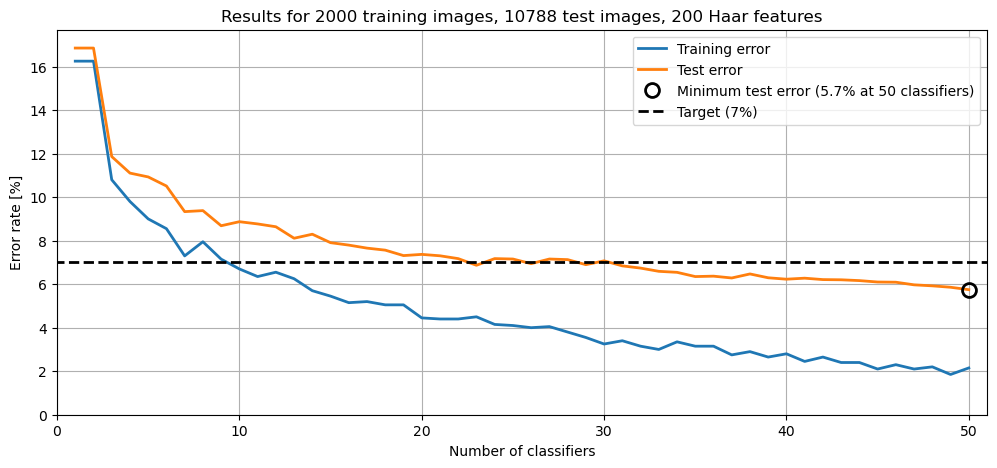

In [14]:
PlotErrorGraphs(ErrTrain, ErrTest, hyperparameters={"nTrain": XTrain.shape[-1], "nTest": XTest.shape[-1], "nFeatures": haarFeatureMasks.shape[-1]})

#### **<span style="color:red">Question 2:</span>**
Suppose you want to deploy your model in a real-world application, for example in a smartphone camera app that can highlight faces. Based on the above result, how many weak classifiers would you choose to include in the model? Motivate your answer.

#### **<span style="color:green">Answer:</span>**

I would choose 50 classifier if I wanted the best results. This is the best result due to having the least amount of test error for the amount of weak classifier used. 

#### **<span style="color:red">Question 3:</span>**
Discuss your choise of hyperparameters
* number of training images
* number of Haar-features
* number of weak classifiers

and how each affect the model performance. What are the advantages and disadvantages to low and high values for each parameter?

#### **<span style="color:green">Answer:</span>**
What I have noticed is that when you have to few training images it leads to bad performance due to not having enough training data and having too many leads training taking a large amount of time.   
Too few Haar-features might lead to not having enough features to accurately describe the image and too many might lead to overfitting.   
Too few weak classifier might lead to underfitting and too many might lead to overfitting

#### **4.1 Investigate the trained model**
Plot some examples of faces and nonfaces that were classified correctly and that were misclassified. To do this, we requre you to find the index in the test data of these four cases:
* Faces classified as faces (F_F)
* Faces classified as nonfaces (F_NF)
* Nonfaces classified as faces (NF_F)
* Nonfaces classified as nonfaces (NF_NF)

There are many ways to do this. It is possible to write each in a single line using numpy functions, although this is not required.

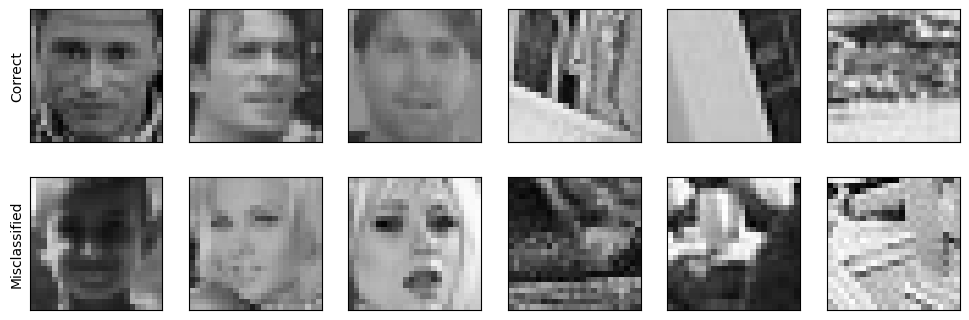

In [47]:
F_F   = np.where((YTest == 1) & (HTest == 1))[0]

F_NF  = np.where((YTest == 1) & (HTest == -1))[0]

NF_F  = np.where((YTest == -1) & (HTest == 1))[0]

NF_NF = np.where((YTest == -1) & (HTest == -1))[0]

PlotClassifications(testImages, F_F, F_NF, NF_NF, NF_F, N=3, selectRandom=True)

#### **<span style="color:red">Question 4:</span>**
Run the above cell a few times and discuss some potential issues in the data that might explain these misclassified images. Can you think of any pre-processing that might improve the results?

#### **<span style="color:green">Answer:</span>**
The misclassified images of faces are often lower quality or more monotone, improving the contrast might help


Run the following code to plot (some) of your selected Haar-features. Feel free to change the paramters `shuffle` and `N`.

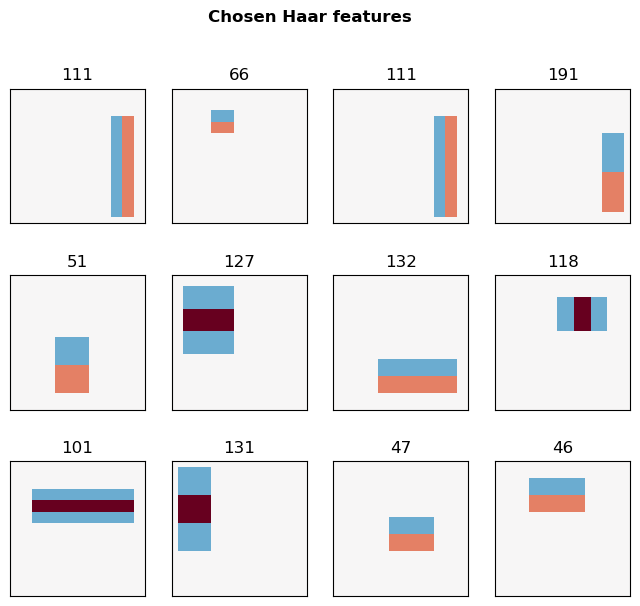

In [51]:
# Inputs:
# - haarFeatureMasks: The list of all generated Haar features
# - selectedIdx: The feature numbers of Haar features selected in the training
# - shuffle (False/True): Select in random order or as they were selected in training
# - N: The number of Haar features to plot

PlotSelectedHaarFeatures(haarFeatureMasks, selectedIdx = optParams[0], shuffle = True, N = 12)

#### **<span style="color:red">Question 5:</span>**
Choose one or two of these Haar-features and speculate what feature of a face this might detect.

#### **<span style="color:green">Answer:</span>**

118: This one might detect the regio of 2 eyes and a nose if a face is correctly behind it  
51: This one might detect and edge of a face or the eye region.


---
### **5. Applying the model on real data**
Evaluating on the test data is, of course, a valid method to measure the objective performance of the model. However, if doesn't really give a feel for how useful the model would actually be in a real world application. This final test applies the model to every 24x24 pixel subimage in this famous photograph of the 1927 Solvay Conference on Physics, and highlights the most likely parts of the image to contain faces.

![](NotebookMaterials/Solvay.png "Famous photo from the 1927 Solvay Conference on Physics.")

Let's see how many of these famous faces your model can find!

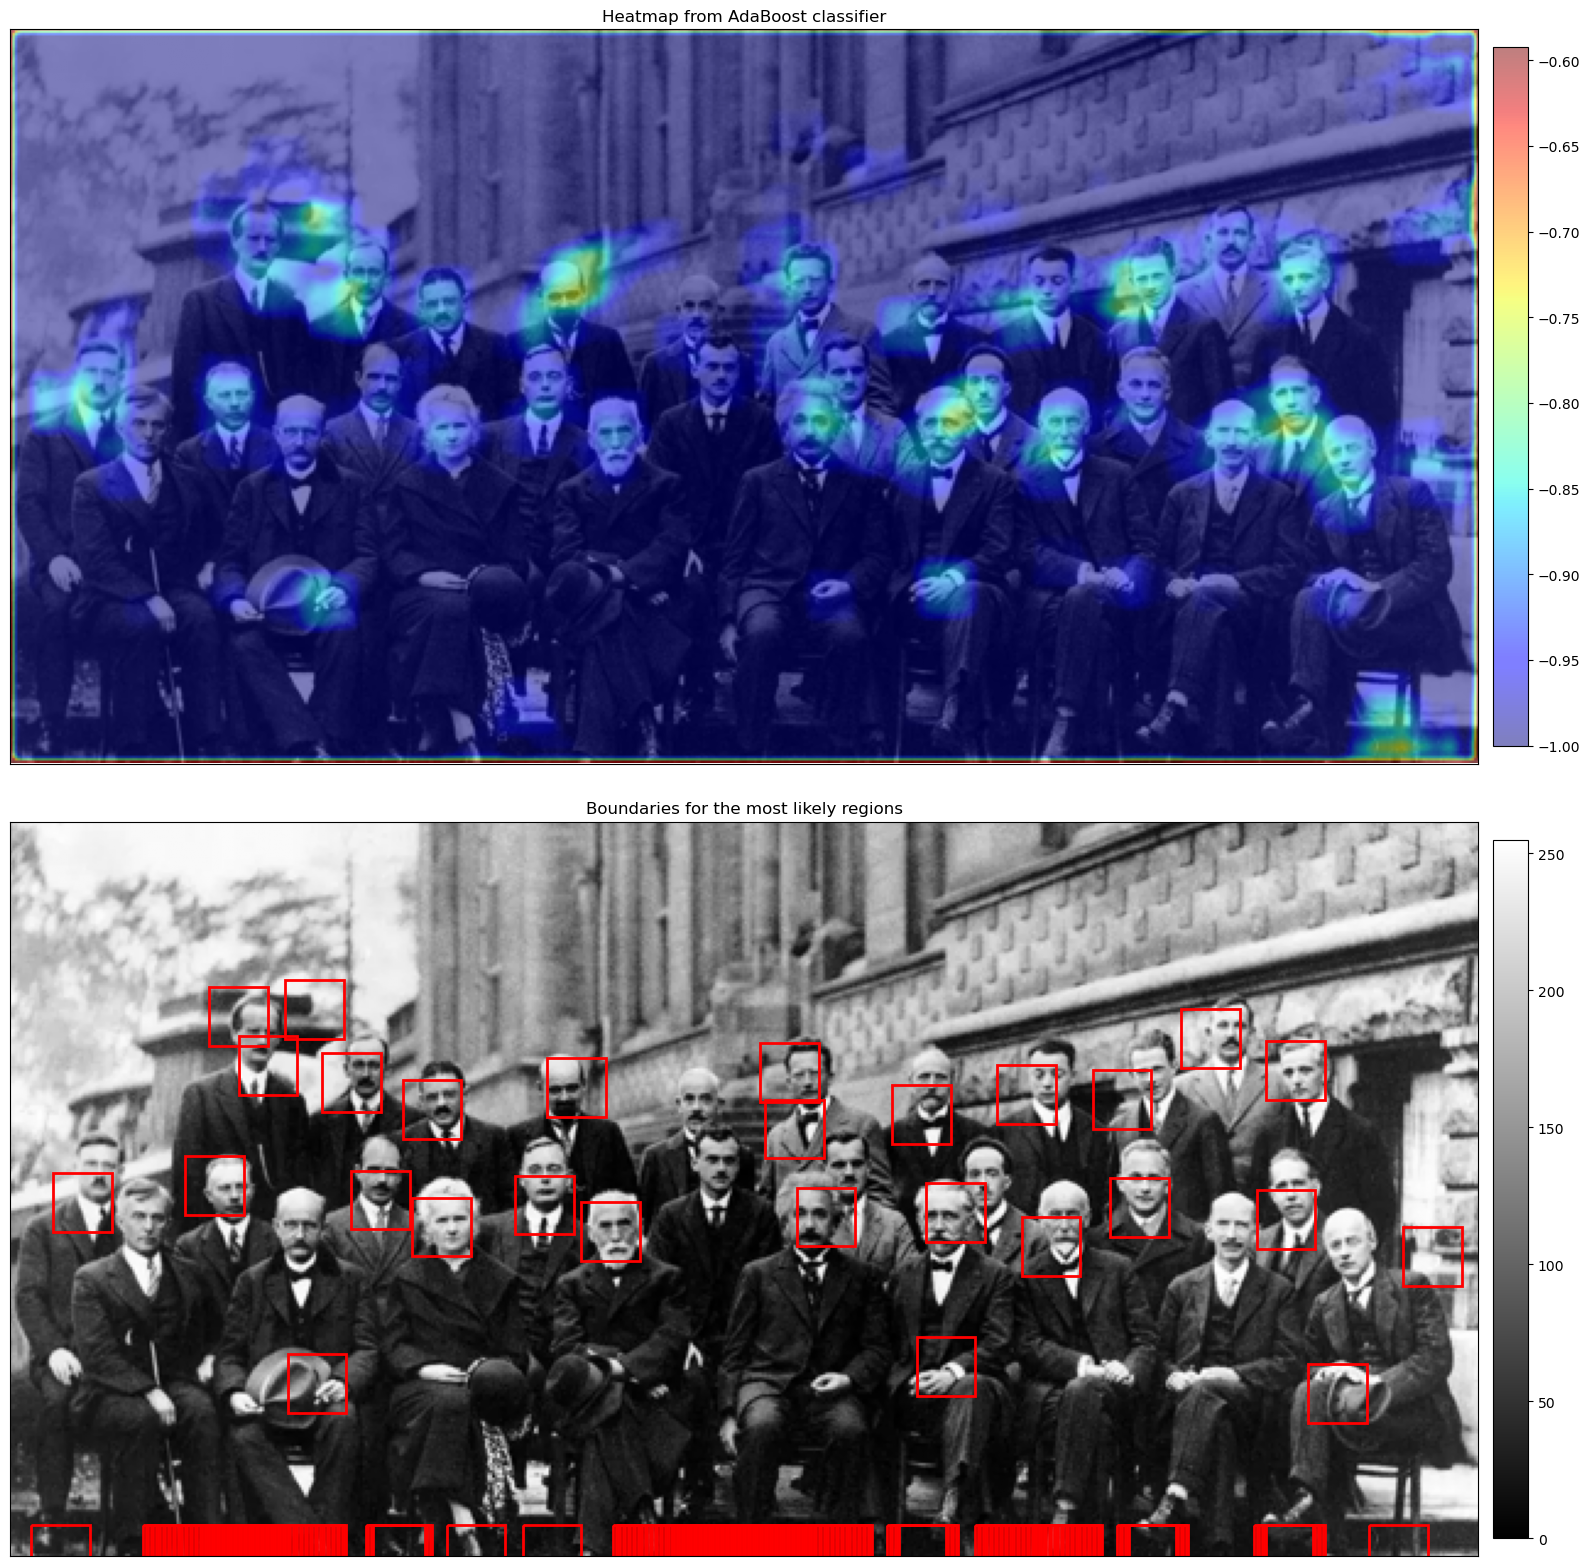

In [59]:
solvay = sio.loadmat('Data/solvay.mat')['X'].astype("float")
xSolvay = ExtractHaarFeatures(solvay, haarFeatureMasks)

cSolvay, _ = StrongClassifier(optParams, xSolvay)

PlotSolvayHeatmap(cSolvay)

#### **<span style="color:red">Question 6:</span>**
Give a final discussion based on all the results. Do you think the model works well? Can you think of any way to improve the results?

#### **<span style="color:green">Answer:</span>**
It works okay for detecting faces but the model is usually off-center and also detects a huge amount of faces in the bottom part of the image for some reason.  
With more data and more finetuning of the hyperparameters i am sure the model can improve more.